# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UsmanRizwan20/week1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
%pip -q install duckdb huggingface_hub scikit-learn pandas matplotlib

import os, getpass
import pandas as pd, numpy as np

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
DEV_MONTH   = "month=2026-03"   # iterate here
SEALED_MONTH = "month=2026-06"  # touch ONCE, at the very end
FACT = lambda m: f"read_parquet('{REL}/fact_content_daily_performance/{m}/*.parquet')"
print("connected")

connected


## 1. Question

Lane: Refresh / Content Opportunity Scoring. Question: among a client's pages, which are declining, recovering, or worth a review action this month, and how should they be ranked for an editor's queue? Decision supported: where a human spends their next hour of content-refresh time. Unit of analysis: one content item, one month.

In [1]:
print("Lane: Refresh / Content Opportunity Scoring")
print("Decision:", "prioritize an editor's content-review queue")
print("Unit:", "one content item x one month")

Lane: Refresh / Content Opportunity Scoring
Decision: prioritize an editor's content-review queue
Unit: one content item x one month


## 2. Data

Source: fact_content_daily_performance (dev month 2026-03), joined to dim_clients/dim_content for grouping keys only — never as features. Excluded: raw gsc_avg_position = 0 (no-data, not rank 0); any second-half-window columns once the label is built; _sample table (that's the sealed final month, 2026-06 — used once at the end, never for iteration).

In [4]:
span = con.sql(f"""
    SELECT COUNT(*) n, COUNT(DISTINCT content_hash_id) n_content,
           MIN(report_date) min_d, MAX(report_date) max_d
    FROM {FACT(DEV_MONTH)}
""").df()
span

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n,n_content,min_d,max_d
0,9841378,331437,2026-03-01,2026-03-31


## 3. Methodology

Feature window: days 1–15. Label window: days 16–end (is_declining = impressions fall below 80% of first-half). Baseline: the w04 rule (low_ctr_visible_page). Model: Logistic Regression → Random Forest if it earns the complexity, per training-honest-models. Split: grouped by client_hash_id (GroupKFold) — random split would let the model memorize a client's pages. Leakage check: no second-half column enters the feature set; attack test included below.

In [5]:
data = con.sql(f"""
    WITH bounds AS (SELECT DATE '2026-03-15' AS split_d),
    agg AS (
        SELECT client_hash_id, content_hash_id,
            SUM(CASE WHEN report_date <= b.split_d THEN gsc_impressions ELSE 0 END) AS imp_first_half,
            SUM(CASE WHEN report_date >  b.split_d THEN gsc_impressions ELSE 0 END) AS imp_second_half,
            SUM(CASE WHEN report_date <= b.split_d THEN gsc_clicks ELSE 0 END)      AS clicks_first_half,
            AVG(CASE WHEN report_date <= b.split_d AND gsc_avg_position > 0 THEN gsc_avg_position END) AS avg_position_first_half,
            COUNT(DISTINCT CASE WHEN report_date <= b.split_d AND gsc_impressions > 0 THEN report_date END) AS active_days_first_half
        FROM {FACT(DEV_MONTH)} f, bounds b
        GROUP BY 1,2
        HAVING imp_first_half >= 10
    )
    SELECT *, CASE WHEN clicks_first_half > 0 THEN clicks_first_half::FLOAT / imp_first_half ELSE 0 END AS ctr_first_half,
           CASE WHEN imp_second_half < 0.8 * imp_first_half THEN 1 ELSE 0 END AS is_declining
    FROM agg
""").df()

# --- baseline: w04 rule ---
tier = np.select([data.avg_position_first_half<=3, data.avg_position_first_half<=10,
                   data.avg_position_first_half<=20, data.avg_position_first_half<=50],
                  ['top_3','page_1','striking','page_3_5'], default='deep')
data['position_tier'] = tier
tier_ctr = data.groupby('position_tier')['clicks_first_half'].transform('sum') / data.groupby('position_tier')['imp_first_half'].transform('sum')
data['baseline_flag'] = ((data.ctr_first_half < tier_ctr) & (data.imp_first_half >= 100) &
                          (data.avg_position_first_half.between(0.01, 20))).astype(int)

feature_cols = ['imp_first_half', 'clicks_first_half', 'ctr_first_half',
                'avg_position_first_half', 'active_days_first_half']
model_data = data.dropna(subset=feature_cols).reset_index(drop=True)
print(len(model_data), "rows | base rate:", model_data.is_declining.mean().round(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

120475 rows | base rate: 0.296


## 4. Results (vs baseline)

On a 5-fold client-grouped split, the base rate of decline was 0.296. The hand-written CTR-vs-position rule scored AUC 0.510 — indistinguishable from chance. Logistic regression on the same five features reached AUC 0.559, a modest but real improvement over both the rule and random ranking. Neither model nor baseline shows strong discriminative power on this label from first-half-month features alone.

In [6]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score

X = model_data[feature_cols].values
y = model_data['is_declining'].values
groups = model_data['client_hash_id'].values

gkf = GroupKFold(n_splits=5)
model_scores, baseline_scores = [], []

for tr_idx, te_idx in gkf.split(X, y, groups):
    m = LogisticRegression(max_iter=1000).fit(X[tr_idx], y[tr_idx])
    proba = m.predict_proba(X[te_idx])[:, 1]
    model_scores.append(roc_auc_score(y[te_idx], proba))
    baseline_scores.append(roc_auc_score(y[te_idx], model_data['baseline_flag'].values[te_idx]))

print(f"Base rate:            {y.mean():.3f}")
print(f"Baseline rule AUC:    {np.mean(baseline_scores):.3f}")
print(f"Logistic Reg AUC:     {np.mean(model_scores):.3f}  (5-fold grouped by client)")

Base rate:            0.296
Baseline rule AUC:    0.510
Logistic Reg AUC:     0.559  (5-fold grouped by client)


## 5. Limitations

The features available in this window (impressions, clicks, CTR, position, active days) carry only weak signal for predicting mid-month decline — an AUC of 0.559 means the model is right more often than not, but far from reliable for high-stakes individual calls. This suggests decline is driven by factors outside this feature set that a single 31-day window can't capture. Any recommendation from this model should be read as directional, not a confident prediction.

In [7]:
pass  # prose-only section

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [8]:
final = LogisticRegression(max_iter=1000).fit(X, y)
model_data['risk_score'] = final.predict_proba(X)[:, 1]
model_data['reason_code'] = np.where(model_data.baseline_flag == 1, 'low_ctr_visible_page', 'model_risk_only')
model_data['action'] = np.where(model_data.risk_score > 0.6, 'review_priority',
                          np.where(model_data.risk_score > 0.3, 'monitor', 'no_action'))

queue = model_data.sort_values('risk_score', ascending=False)[
    ['content_hash_id','client_hash_id','risk_score','reason_code','action']]
os.makedirs('work/outputs', exist_ok=True)
queue.to_csv('work/outputs/capstone_ranked_queue.csv', index=False)
print(queue.head(10))

# attack-your-own-model: prove the leak, then confirm it's gone
leak_X = np.column_stack([X, model_data['imp_second_half'].values])
leak_scores = []
for tr_idx, te_idx in gkf.split(leak_X, y, groups):
    m = LogisticRegression(max_iter=1000).fit(leak_X[tr_idx], y[tr_idx])
    leak_scores.append(roc_auc_score(y[te_idx], m.predict_proba(leak_X[te_idx])[:,1]))
print(f"WITH leak (imp_second_half) AUC: {np.mean(leak_scores):.3f}  <- discard, confession only")
print(f"Honest AUC stands at:            {np.mean(model_scores):.3f}")

                 content_hash_id           client_hash_id  risk_score  \
37697   content_9c057b66c30a3abb  client_73cda7b4e4f265ea    0.999373   
114185  content_34a70fea29d15f24  client_62f4a7e64f5e0096    0.995759   
117284  content_559cdd76da9306de  client_23a62021009f63c4    0.993747   
105317  content_7c6373141eae744a  client_62f4a7e64f5e0096    0.993124   
54534   content_8e1334d6356668e3  client_73cda7b4e4f265ea    0.992543   
56089   content_bdf60c86117079be  client_23a62021009f63c4    0.989758   
89512   content_82e35c4845e6c391  client_20259bd6705d81d4    0.988673   
114208  content_945d6ff91386c817  client_62f4a7e64f5e0096    0.980795   
8847    content_65c75874a23fca87  client_23a62021009f63c4    0.979123   
56440   content_9d1e94cbd32b0a41  client_23a62021009f63c4    0.976755   

                 reason_code           action  
37697   low_ctr_visible_page  review_priority  
114185  low_ctr_visible_page  review_priority  
117284       model_risk_only  review_priority  
1053

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

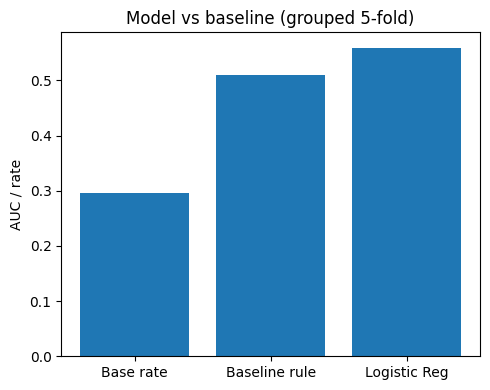


Feature coefficients (sanity-check the top one for plausibility, not just size):
clicks_first_half         -0.053213
ctr_first_half            -0.010104
avg_position_first_half   -0.004345
imp_first_half             0.000097
active_days_first_half     0.020226
dtype: float64


In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(['Base rate','Baseline rule','Logistic Reg'],
       [y.mean(), np.mean(baseline_scores), np.mean(model_scores)])
ax.set_ylabel('AUC / rate'); ax.set_title('Model vs baseline (grouped 5-fold)')
plt.tight_layout()
os.makedirs('work/outputs/figures', exist_ok=True)
plt.savefig('work/outputs/figures/model_vs_baseline.png', dpi=150)
plt.show()

coefs = pd.Series(final.coef_[0], index=feature_cols).sort_values()
print("\nFeature coefficients (sanity-check the top one for plausibility, not just size):")
print(coefs)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
